# Saisonnalité & Tendances

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")

## Evolution des ventes dans le temps

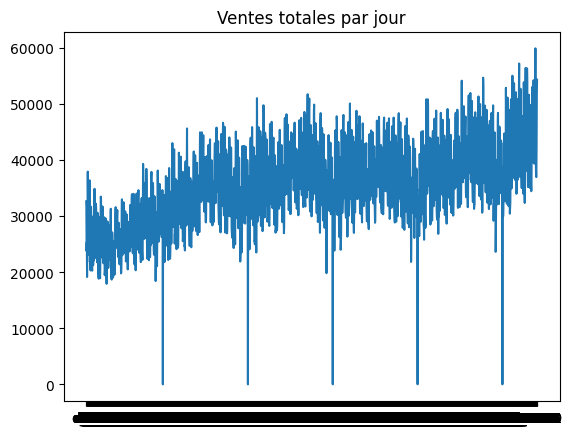

In [4]:
# colonnes des ventes
colonnes_ventes = [c for c in df.columns if c.startswith("d_")]

# somme des ventes pour chaque jours
ventes_par_jour = df[colonnes_ventes].sum()

# Graphique
plt.plot(ventes_par_jour)
plt.title("Ventes totales par jour")
plt.show()

Les ventes montrent une tendance légèrement croissante le long de la période. 
    
On observe néanmoins 5 pics majeurs négatifs espacés régulièrement. Ces pics sont probablement dus à une saisonnalité annuelle (environ 1 pic par an) de faible consommation. 

## Evolution des ventes dans le temps avec lissage par semaine

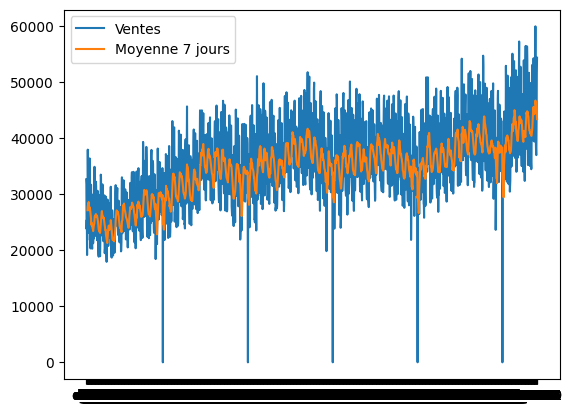

In [5]:
moyenne_7j = ventes_par_jour.rolling(7).mean()

plt.plot(ventes_par_jour, label="Ventes")
plt.plot(moyenne_7j, label="Moyenne 7 jours")
plt.legend()
plt.show()

La moyenne sur 7 jours montre une structure en montée puis descente entre chacun des pics négatifs. Les ventes ne sont donc pas aléatoires : elles augmenrent après le pic puis re-diminuent avant le suivant.

## Les jours avec le plus de ventes

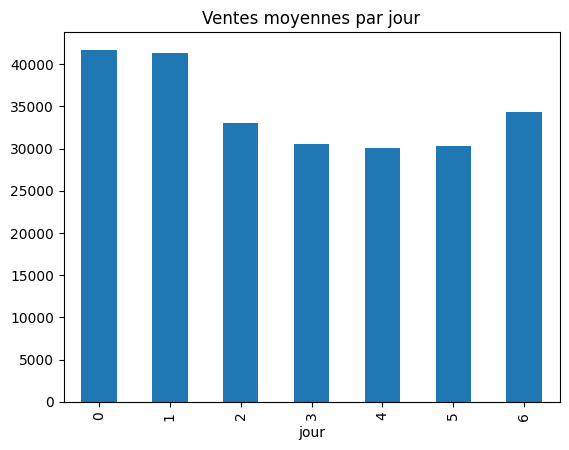

In [6]:
# on créer un jour artificiel
jours = [i%7 for i in range(len(ventes_par_jour))]

df_jour = pd.DataFrame({
    "ventes" : ventes_par_jour,
    "jour" : jours
})

# moyenne par jour
moyenne_par_jour = df_jour.groupby("jour")["ventes"].mean()

# graphique
moyenne_par_jour.plot(kind = 'bar')
plt.title("Ventes moyennes par jour")
plt.show()

Les jours 0 et 1 ont des ventes nettement plus élevées, tandis que les autres sont plus faibles. Il existe donc une saisonnalité hebdomadaire : certains jours concentrent plus de ventes.

## Détection des pics de ventes

In [7]:
# on créer un seuil pour avoir le top 5% des ventes
seuil = ventes_par_jour.quantile(0.95)

pics = ventes_par_jour[ventes_par_jour > seuil]

print(pics)

d_736     51032
d_764     49772
d_765     48247
d_856     47502
d_863     48164
          ...  
d_1926    54239
d_1933    54308
d_1934    59921
d_1940    51518
d_1941    54338
Length: 97, dtype: int64


97 jours sont identifiés comme pics (top 5%). Les pics ne sont pas isolés : ils apparaissent en groupe de jours proches. Il y a donc très probablement des périodes de forte activité.

## Comparatif des catégories

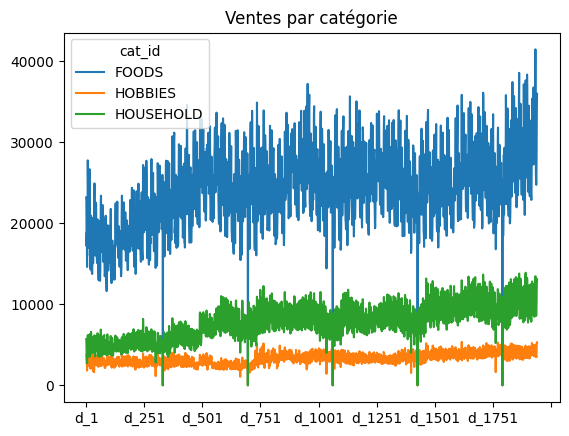

In [8]:
# somme par catégorie 
df_cat = df.groupby("cat_id")[colonnes_ventes].sum().T
df_cat.plot()
plt.title("Ventes par catégorie")
plt.show()

Par catégorie, FOODS domine largement et a la même forme que courbe globale. HOUSEHOLD est intermédiaire et HOBBIES est plus faible. Les pics négatifs apparaissent au même moment pour toutes les catégories.

## Conclusion

Il existe une double saisonnalité : une annuelle que l'on observe avec les pics négatifs réguliers et une hebdomadaire que l'on observe avec les variations selon les jours.

Au global, sur 5 ans, on observe une montée progressive des catégories food et household et plus légère pour Hobbies.